# Escherichia Coli Metabolism Analysis

## 0. Tasks

**Easy**

Download, compile and run a flux sampling analysis on the core model of E.coli (e_coli_core) requiring: i. for optimal biomass growth, ii. for at least half of the optimal, and iii. setting biomass free.

**Medium**

Exploit dingo's functionalities to come up with reaction clusters differentiating in each case.

**Hard**

Try to interpret your findings. Then, describe how you would set a pipeline to address the problem described above.

## 1. Requirements

In [ ]:
!python --version

In [38]:
import numpy as np
import pandas as pd
import plotly.express as px

import os
import sys
import json
import pickle
import time
import math

# --- THE FIX: ADD DINGO TO PYTHON's PATH ---
# This looks one folder up ('..') from 'code', and points into the 'dingo' folder
dingo_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'dingo'))
if dingo_path not in sys.path:
    sys.path.insert(0, dingo_path)
# -------------------------------------------

import dingo
from dingo.MetabolicNetwork import MetabolicNetwork
from dingo.PolytopeSampler import PolytopeSampler
from dingo import plot_histogram, plot_copula

### 2. Load Model

In [39]:
os.getcwd()

'/mnt/d/projects/gsoc/flux-sampling/code'

In [40]:
model = MetabolicNetwork.from_json("../data/e_coli_core.json")

In [41]:
print(f"Number of metabolites: \t\t\t{len(model.metabolites)}\nNumber of reactions:\t\t\t{len(model.reactions)}")
print(f"Stoichiometric matrix dimensions:\t{model.S.shape}")
print(f"Objective Function: \n{model.objective_function}")
print(f"\n\n ----- Other parameters: -----\n {model.parameters}")

Number of metabolites: 			72
Number of reactions:			95
Stoichiometric matrix dimensions:	(72, 95)
Objective Function: 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


 ----- Other parameters: -----
 {'opt_percentage': 100, 'distribution': 'uniform', 'nullspace_method': 'sparseQR', 'solver': None}


### 3. Introduction to Dingo

#### 3.1 Perform Flux Balance Analysis

In [17]:
fba = model.fba()

max_biomass_flux = fba[0]
max_biomass_objective = fba[1]

In [25]:
print(f"----- FBA ----- \nMaximum biomass flux: \n{max_biomass_flux}\n\nMaximum biomass objective: \t\t {max_biomass_objective}")

----- FBA ----- 
Maximum biomass flux: 
[  7.47738196   0.           4.86086115 -16.02352614   4.95998494
  -0.          -0.         -14.71613957   3.21489505  -0.
  -0.          -0.           2.50430947   6.00724958   6.00724958
   8.39         0.          -0.           0.          -0.
   5.06437566  45.51400977  -0.           1.75817744   0.87392151
  -0.         -22.80983331   2.67848185   6.00724958  -2.28150309
  -0.          43.59898531  -0.          14.71613957   0.
  -0.           5.06437566  -5.06437566   1.49698376   0.
   1.49698376   1.18149809   7.47738196   0.           0.
   0.          22.80983331   0.          -0.           0.
   0.         -10.           0.           0.          17.53086543
  29.17582714   0.           0.          -4.76531919 -21.79949266
  -3.21489505   0.           0.           7.47738196   0.
  -0.           0.           0.          -0.           5.06437566
  -0.           4.95998494  16.02352614  10.           0.22346173
  -0.          -4.54185746

#### 3.2 Perform Flux Variability Analysis

In [27]:
fva = model.fva()

min_fluxes = fva[0]
max_fluxes = fva[1]
fva_max_biomass_flux = fva[2]
fva_max_biomass_objective = fva[3]

In [31]:
print(f"---- FVA ----- \nMaximum biomass flux:\n{fva_max_biomass_flux}\n\nMaximum biomass objective: \t\t {fva_max_biomass_objective}")

---- FVA ----- 
Maximum biomass flux:
[  7.47738196   0.           4.86086115 -16.02352614   4.95998494
  -0.          -0.         -14.71613957   3.21489505  -0.
  -0.          -0.           2.50430947   6.00724958   6.00724958
   8.39         0.          -0.           0.          -0.
   5.06437566  45.51400977  -0.           1.75817744   0.87392151
  -0.         -22.80983331   2.67848185   6.00724958  -2.28150309
  -0.          43.59898531  -0.          14.71613957   0.
  -0.           5.06437566  -5.06437566   1.49698376   0.
   1.49698376   1.18149809   7.47738196   0.           0.
   0.          22.80983331   0.          -0.           0.
   0.         -10.           0.           0.          17.53086543
  29.17582714   0.           0.          -4.76531919 -21.79949266
  -3.21489505   0.           0.           7.47738196   0.
  -0.           0.           0.          -0.           5.06437566
  -0.           4.95998494  16.02352614  10.           0.22346173
  -0.          -4.54185746  

#### 3.3 Perform Flux Sampling Analysis

In [32]:
sampler = PolytopeSampler(model)

In [33]:
steady_states = sampler.generate_steady_states(ess = 1000, psrf = True)
reactions = model.reactions

phase 1: number of correlated samples = 500, effective sample size = 4, ratio of the maximum singilar value over the minimum singular value = 1489.39
phase 2: number of correlated samples = 500, effective sample size = 14, ratio of the maximum singilar value over the minimum singular value = 161.182
phase 3: number of correlated samples = 500, effective sample size = 14, ratio of the maximum singilar value over the minimum singular value = 167.013
phase 4: number of correlated samples = 500, effective sample size = 14, ratio of the maximum singilar value over the minimum singular value = 46.8356
phase 5: number of correlated samples = 500, effective sample size = 163, ratio of the maximum singilar value over the minimum singular value = 2.71043
phase 6: number of correlated samples = 2000, effective sample size = 799
[4]total ess 1008: number of correlated samples = 4500


[4]maximum marginal PSRF: 1.02032


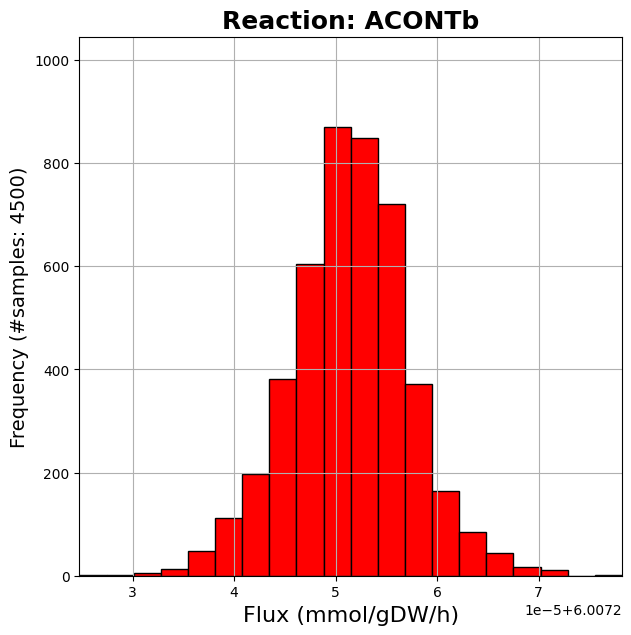

In [34]:
plot_histogram(steady_states[14], reactions[14], n_bins=20)

In [36]:
plot_copula([steady_states[18], reactions[18]], [steady_states[15], reactions[15]], n=20)

### 4. Task 1